In [33]:
from dataclasses import dataclass
import numpy as np
import nn
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
n = 10_000
theta = 6 * np.pi * np.random.random(n).reshape((n, 1))
r = 6 * np.pi * np.random.random(n).reshape((n, 1))
y = np.abs((r - theta) % (2 * np.pi)).flatten() < np.pi
X = r * np.concatenate([np.cos(theta), np.sin(theta)], axis=1)

In [20]:
X

array([[-2.25865915, 13.72880708],
       [15.13639184,  4.03296744],
       [ 0.89216482, -0.640605  ],
       ...,
       [-9.75249826, -7.81587069],
       [ 4.95001613,  4.68306067],
       [ 3.41447384, 16.28801417]], shape=(10000, 2))

In [427]:
l1 = nn.Linear(1 / (X.std() * np.sqrt(2)) * np.random.normal(size=(10, 2)))
act1 = nn.Max0()
l2 = nn.Linear(1 / np.sqrt(10) * np.random.normal(size=(10, 10)))
act2 = nn.Max0()
l3 = nn.Linear(1 / np.sqrt(10) * np.random.normal(size=(1, 10)))
act3 = nn.MapTo01()   

layers = [l1, act1, l2, act2, l3, act3]
neural_network = nn.NN(layers)

In [5]:
X[0,:], y[0]

(array([13.42117886,  2.9721554 ]), np.True_)

In [429]:
random_sample = range(10,20)#np.random.choice(len(X), size=10, replace=False)

for training_iteration in range(100):
    for i in random_sample:
        loss_function = nn.SquaredErrorLoss()
        output = neural_network.run(X[i,:])
        print(f"output: {output}")
        loss = loss_function.get_loss(output, y[i])
        print(f"loss: {loss}")
        output_gradient = loss_function.output_gradient(output, y[i])
        print(f"output_gradient: {output_gradient}")
        neural_network.update(output_gradient, learning_rate=0.01, regularization=0.00001)

output: [0.54226491]
loss: [0.29405123]
output_gradient: [1.08452981]
output: [0.38722017]
loss: [0.14993946]
output_gradient: [0.77444034]
output: [0.29152819]
loss: [0.08498868]
output_gradient: [0.58305637]
output: [0.61631743]
loss: [0.37984718]
output_gradient: [1.23263487]
output: [0.50037528]
loss: [0.24962487]
output_gradient: [-0.99924945]
output: [0.6380456]
loss: [0.13101099]
output_gradient: [-0.72390881]
output: [0.39677637]
loss: [0.36387874]
output_gradient: [-1.20644725]
output: [0.62701487]
loss: [0.1391179]
output_gradient: [-0.74597025]
output: [0.65027988]
loss: [0.12230416]
output_gradient: [-0.69944023]
output: [0.61015698]
loss: [0.15197758]
output_gradient: [-0.77968604]
output: [0.54288291]
loss: [0.29472185]
output_gradient: [1.08576581]
output: [0.38403897]
loss: [0.14748593]
output_gradient: [0.76807793]
output: [0.28745339]
loss: [0.08262945]
output_gradient: [0.57490678]
output: [0.61814024]
loss: [0.38209735]
output_gradient: [1.23628048]
output: [0.50041

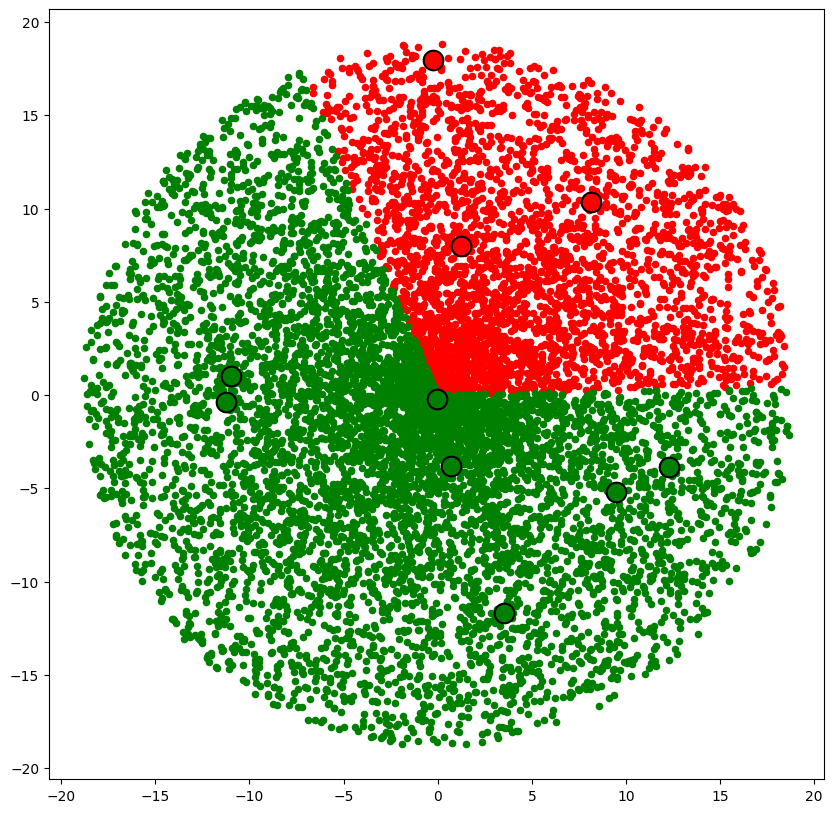

In [430]:
all_points=X
all_predictions = np.array([neural_network.run(x) for x in all_points]).flatten() > 0.5

plt.rcParams["figure.figsize"] = (10, 10)

plt.scatter(X[~all_predictions, 0], X[~all_predictions, 1], color="r", s=20)
plt.scatter(X[all_predictions, 0], X[all_predictions, 1], color="g", s=20)


sample_points=np.array([X[i,:] for i in random_sample])
sample_predictions = np.array([neural_network.run(x) for x in sample_points]).flatten() > 0.5
plt.scatter(sample_points[~sample_predictions, 0], sample_points[~sample_predictions, 1], 
            color="r", s=200, edgecolors="black", linewidths=1.5)
plt.scatter(sample_points[sample_predictions, 0], sample_points[sample_predictions, 1], 
            color="g", s=200, edgecolors="black", linewidths=1.5)


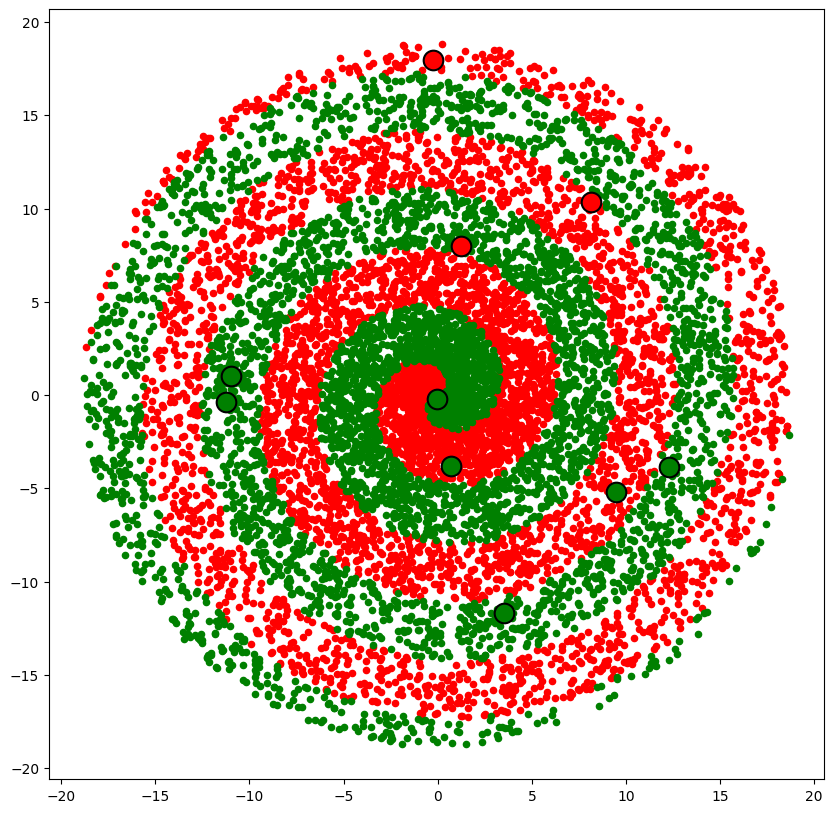

In [431]:
sample_points=np.array([X[i,:] for i in random_sample])
sample_predictions = np.array([neural_network.run(x) for x in sample_points]).flatten() > 0.5

plt.rcParams["figure.figsize"] = (10, 10)

plt.scatter(X[~y, 0], X[~y, 1], color="r", s=20)
plt.scatter(X[y, 0], X[y, 1], color="g", s=20)

plt.scatter(sample_points[~sample_predictions, 0], sample_points[~sample_predictions, 1], 
            color="r", s=200, edgecolors="black", linewidths=1.5)
plt.scatter(sample_points[sample_predictions, 0], sample_points[sample_predictions, 1], 
            color="g", s=200, edgecolors="black", linewidths=1.5)



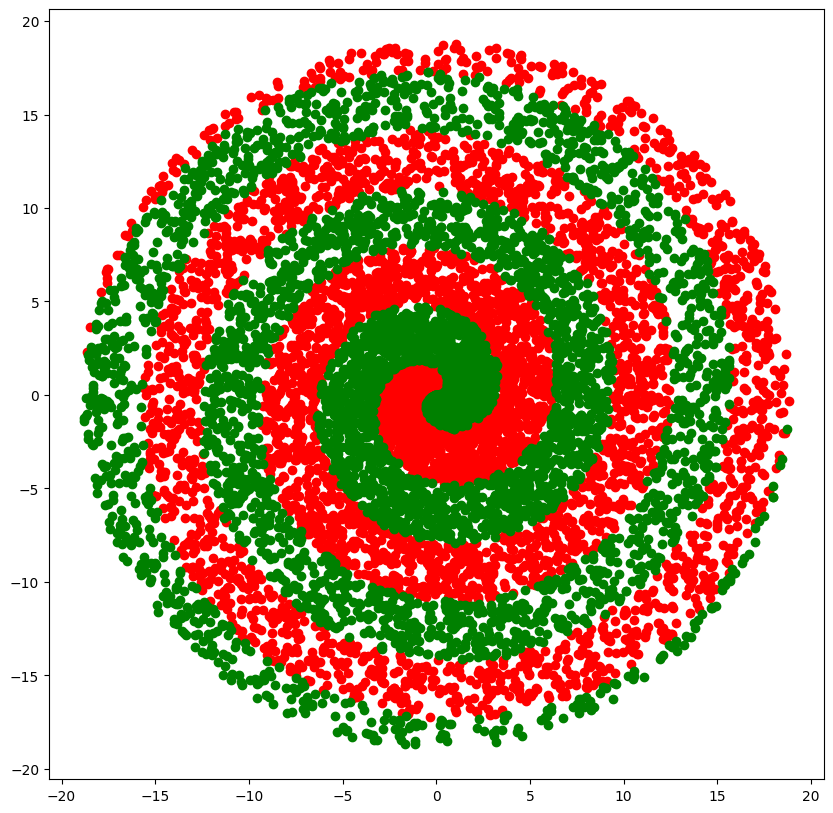

In [93]:
plt.rcParams["figure.figsize"] = (10, 10)
plt.scatter(X[~y, 0], X[~y, 1], color="r")
plt.scatter(X[y, 0], X[y, 1], color="g")

In [4]:
np.arange(6).reshape((3,2))

array([[0, 1],
       [2, 3],
       [4, 5]])

In [6]:
np.arange(1,4).reshape((1,3)) * (10 * np.arange(1,3)).reshape((2,1))

array([[10, 20, 30],
       [20, 40, 60]])